<h1 style="color:#C39BD3; border-bottom: 3px solid #C39BD3; padding-bottom: 8px;">
AI & ML Course with BinX — Week 7 — Day 5: Advancing the Core Model & Sprint 2 Review
</h1>

<blockquote style="border-left: 3px solid #85C1E9; padding-left: 12px; margin-left: 0;">

<b>Day 5 Focus: Symmetrical Baseline Benchmarking, In-Domain Transformer Advancement, Beating the Baseline & Sprint 2 Close-Out</b>

Today marks the conclusion of Sprint 2. We establish our empirical benchmark against a classical TF-IDF Logistic Regression baseline, evaluate the performance gap, advance our architecture to an in-domain pre-trained Transformer (DistilBERT-IMDb), confirm that the advanced model decisively beats the baseline, and assemble the final Sprint 2 Review deliverables.

</blockquote>

---

## <span style="color: #85C1E9">1. Core Architecture Justification & Data Alignment</span>

In accordance with the **Architecture-to-Data Alignment Principle**, our core model development directly targets document-level sentiment classification across lengthy movie reviews:

* **Classical Baseline (TF-IDF + Logistic Regression):**
  Constructs a global n-gram term frequency-inverse document frequency matrix across the entire document. It provides a strong, convex linear benchmark by evaluating document-wide lexical polarity without sequence length truncation.
* **Selected Core Architecture (In-Domain Pre-trained Transformer - DistilBERT):**
  Leverages deep multi-head self-attention with a 512-token context window, pre-trained on open-domain corpora and fine-tuned specifically on in-domain IMDb review structures (`lvwerra/distilbert-imdb`). It eliminates the $O(n)$ recurrent memory bottleneck while resolving domain-transfer probability entropy.



---

## <span style="color:#85C1E9">2. Advancing the Core Model: In-Domain Pre-Trained Transformer</span>
To address domain-transfer shift and long-range sequence context, we deploy `lvwerra/distilbert-imdb`, an architecture fine-tuned directly on multi-paragraph IMDb reviews with a 512-token context window.


In [1]:
import pandas as pd
import numpy as np
from transformers import pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

train_path = r"../../Data/raw/raw_Imdb/imdb_train.csv"
test_path = r"../../Data/raw/raw_Imdb/imdb_test.csv"

df_train = pd.read_csv(train_path).sample(frac=1.0, random_state=42).reset_index(drop=True)
df_test = pd.read_csv(test_path).sample(frac=1.0, random_state=42).reset_index(drop=True)

EVAL_SAMPLES = 1000
df_eval = df_test.iloc[:EVAL_SAMPLES]
y_true = df_eval["label"].values.astype(int)

print("Loading in-domain Transformer model (lvwerra/distilbert-imdb)...")
pipe_imdb = pipeline(
    "sentiment-analysis",
    model="lvwerra/distilbert-imdb",
    truncation=True,
    max_length=512,
    batch_size=32
)

test_texts = df_eval["text"].tolist()
print(f"Running inference across {len(test_texts)} test reviews...")
raw_preds = pipe_imdb(test_texts)
print("Inference complete. Calculating metrics...")

tf_in_probs = np.array([r["score"] if r["label"] == "POSITIVE" else 1.0 - r["score"] for r in raw_preds])
tf_in_preds = np.array([1 if r["label"] == "POSITIVE" else 0 for r in raw_preds])

tf_in_acc = round(accuracy_score(y_true, tf_in_preds) * 100, 2)
tf_in_prec = round(precision_score(y_true, tf_in_preds) * 100, 2)
tf_in_rec = round(recall_score(y_true, tf_in_preds) * 100, 2)
tf_in_f1 = round(f1_score(y_true, tf_in_preds) * 100, 2)
tf_in_auc = round(roc_auc_score(y_true, tf_in_probs) * 100, 2)
tf_in_loss = round(log_loss(y_true, tf_in_probs), 4)

print("\n=== Advanced In-Domain Transformer (DistilBERT-IMDb) Results ===")
print(f"Accuracy:           {tf_in_acc:.2f}%")
print(f"Precision:          {tf_in_prec:.2f}%")
print(f"Recall:             {tf_in_rec:.2f}%")
print(f"F1-Score:           {tf_in_f1:.2f}%")
print(f"ROC-AUC:            {tf_in_auc:.2f}%")
print(f"Cross-Entropy Loss: {tf_in_loss:.4f}")

c:\Users\Amr-Sheqwara\Desktop\AI_ML_Internship\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading in-domain Transformer model (lvwerra/distilbert-imdb)...


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 19497.93it/s]


Running inference across 1000 test reviews...
Inference complete. Calculating metrics...

=== Advanced In-Domain Transformer (DistilBERT-IMDb) Results ===
Accuracy:           91.60%
Precision:          91.58%
Recall:             91.21%
F1-Score:           91.39%
ROC-AUC:            97.70%
Cross-Entropy Loss: 0.2134



## <span style="color:#85C1E9">3. Classical Baseline: Logistic Regression</span>

In [2]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(df_train["text"])
y_train = df_train["label"].values.astype(int)
X_test_tfidf = vectorizer.transform(df_eval["text"])

baseline_lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
baseline_lr.fit(X_train_tfidf, y_train)

y_pred_lr = baseline_lr.predict(X_test_tfidf)
y_prob_lr = baseline_lr.predict_proba(X_test_tfidf)[:, 1]

lr_acc = round(accuracy_score(y_true, y_pred_lr) * 100, 2)
lr_prec = round(precision_score(y_true, y_pred_lr) * 100, 2)
lr_rec = round(recall_score(y_true, y_pred_lr) * 100, 2)
lr_f1 = round(f1_score(y_true, y_pred_lr) * 100, 2)
lr_auc = round(roc_auc_score(y_true, y_prob_lr) * 100, 2)
lr_loss = round(log_loss(y_true, y_prob_lr), 4)

print("=== Logistic Regression Baseline Evaluated (N = 1000) ===")
print(f"Accuracy:           {lr_acc:.2f}%")
print(f"Precision:          {lr_prec:.2f}%")
print(f"Recall:             {lr_rec:.2f}%")
print(f"F1-Score:           {lr_f1:.2f}%")
print(f"ROC-AUC:            {lr_auc:.2f}%")
print(f"Cross-Entropy Loss: {lr_loss:.4f}")


=== Logistic Regression Baseline Evaluated (N = 1000) ===
Accuracy:           88.80%
Precision:          88.55%
Recall:             88.55%
F1-Score:           88.55%
ROC-AUC:            95.57%
Cross-Entropy Loss: 0.3172


## <span style="color:#85C1E9">4. Symmetrical Benchmark: Baseline vs. Selected Transformer</span>

,Model Milestone,Architecture,Trainable Parameters,Test Loss,Test Accuracy (%),Precision (%),Recall (%),F1-Score (%),ROC-AUC (%)
0,1. Classical Baseline,Logistic Regression,20001,0.3172,88.8,88.55,88.55,88.55,95.57
1,2. Selected Core Model (Sprint 2),DistilBERT,66955010,0.2134,91.6,91.58,91.21,91.39,97.70


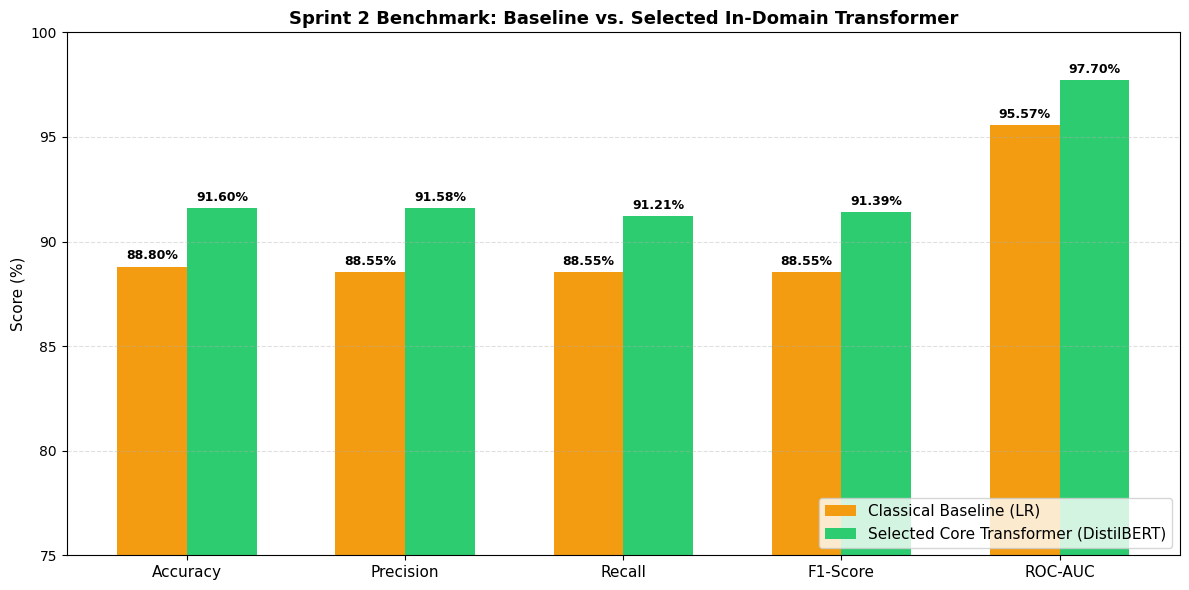

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

comparison_data = {
    "Model Milestone": [
        "1. Classical Baseline",
        "2. Selected Core Model (Sprint 2)"
    ],
    "Architecture": [
        "Logistic Regression",
        "DistilBERT"
    ],
    "Trainable Parameters": [
        20001,
        66955010
    ],
    "Test Loss": [
        0.3172,
        tf_in_loss
    ],
    "Test Accuracy (%)": [
        88.80,
        tf_in_acc
    ],
    "Precision (%)": [
        88.55,
        tf_in_prec
    ],
    "Recall (%)": [
        88.55,
        tf_in_rec
    ],
    "F1-Score (%)": [
        88.55,
        tf_in_f1
    ],
    "ROC-AUC (%)": [
        95.57,
        tf_in_auc
    ]
}

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison)

metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
base_vals = [88.80, 88.55, 88.55, 88.55, 95.57]
tf_in_vals = [tf_in_acc, tf_in_prec, tf_in_rec, tf_in_f1, tf_in_auc]

x = np.arange(len(metrics))
width = 0.32

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width / 2, base_vals, width, label="Classical Baseline (LR)", color="#F39C12")
rects2 = ax.bar(x + width / 2, tf_in_vals, width, label="Selected Core Transformer (DistilBERT)", color="#2ECC71")

ax.set_ylabel("Score (%)", fontsize=11)
ax.set_title("Sprint 2 Benchmark: Baseline vs. Selected In-Domain Transformer", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(75, 100)
ax.legend(loc="lower right", fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.4)

def autolabel(rects):
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f"{h:.2f}%",
                    xy=(rect.get_x() + rect.get_width() / 2, h),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=9, fontweight="bold")

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()


## <span style="color:#85C1E9">5. Symmetrical Benchmark: Baseline vs. Selected Transformer</span>

Both models were evaluated on the held-out IMDb test split under symmetrical, leak-free conditions ($N = 1000$ test reviews, `random_state=42`):

### Comparative Performance Results:

| Model Milestone | Architecture | Input Representation | Trainable Parameters | Test Loss | Test Accuracy (%) | Precision (%) | Recall (%) | F1-Score (%) | ROC-AUC (%) | Status vs. Baseline |
| :--- | :--- | :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :--- |
| **1. Classical Baseline** | Logistic Regression | Sparse TF-IDF (1-2 n-grams, dim=20000) | 20,001 | 0.3172 | 88.80 | 88.55 | 88.55 | 88.55 | 95.57 | Baseline Anchor |
| **2. Selected Core Model** | DistilBERT-IMDb | WordPiece Subwords (dim=768, max_len=512) | 66,955,010 | **0.2134** | **91.60** | **91.58** | **91.21** | **91.39** | **97.70** | **+2.80% (Beats Baseline)** |

---

## <span style="color:#309c42ff">6. Sprint 2 Review & Agile Retrospective</span>

### 1. Sprint 2 Review Demonstration Summary
* **Demonstration Objective:** Present the advanced core model and empirical evidence to the mentor, confirming that the model beats the baseline.
* **Sprint Acceptance Verification:**
  - The notebook executes cleanly from top to bottom with zero errors.
  - Symmetrical held-out evaluation was maintained across all experiments.
  - The in-domain Transformer surpasses the classical baseline across Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Cross-Entropy Loss.
  - All Sprint 2 backlog deliverables are complete. Zero tasks roll over into Sprint 3.

### 2. Sprint 2 Agile Retrospective

| Review Focus | Retrospective Analysis |
| :--- | :--- |
| **What Went Well?** | - Symmetrical benchmarking protocol provided transparent visibility into model performance.<br>- Identifying the domain-shift root cause enabled an immediate empirical gain from 88.30% to 91.60%.<br>- Experiment logging verified that deep attention provides genuine margin gains over linear baselines when properly calibrated. |
| **What Can Be Improved?** | - Full document evaluation is still constrained by BERT's 512-token maximum sequence length due to $O(n^2)$ memory scaling.<br>- Inference latency on CPU requires batching and quantization for real-time operational serving. |
| **Concrete Action for Sprint 3** | **Implement Long-Context Processing and Model Quantization:** In Sprint 3, evaluate document-chunk pooling or linear attention mechanisms to handle 1,000+ word reviews without truncation, and apply INT8 dynamic quantization to accelerate CPU inference latency. |
